El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales donde se emplean filtros de 3x3 y 5x5 en cada capa y se concatenan las salida para la entrada a la capa siguiente

Importación de librerías

In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose, Concatenate, Activation # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
import matplotlib.pyplot as plt

Funciones

In [3]:
# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)


In [4]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [5]:
# Directorio con imagenes en tamaño original y  tamaño reducido
d_original = 'E:/bandas/banda13/ene_01_mes'
d_reducida = 'E:/bandas/banda13/ene_01_reducida_mes'

#Llamado de función para redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]  # Limita los valores al rango [0, 1]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

Procesando 741 imágenes
Forma de X: (740, 480, 480, 1)
Forma de y: (740, 480, 480, 1)


Creación de un modelo simple de redes neuronales convolucionales

In [7]:

# Semilla
semilla = 42
tf.random.set_seed(semilla)

# Entrada
inputs = Input(shape=X.shape[1:])

# === Bloque 1 ===
x1_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(inputs)
x1_5 = Conv2D(16, (5, 5), padding='same', activation='relu')(inputs)

res1 = Concatenate()([x1_3, x1_5])

# === Bloque 2 ===
x2_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res1)
x2_5 = Conv2D(16, (5, 5), padding='same', activation= 'relu')(res1)

# 🔗 Conexión residual (concatenación)
res2 = Concatenate()([x2_3, x2_5])
res2 = res2 + res1
res2 = Activation('relu')(res2)

# === Bloque 3 ===
x3_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res2)
x3_5 = Conv2D(16, (5, 5), padding='same', activation= 'relu')(res2)

# 🔗 Conexión residual (concatenación)
res3 = Concatenate()([x3_3, x3_5])
res3 = res3 + res2
res3 = Activation('relu')(res3)

# === Bloque 4 (reducción de canales) ===
x4_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res3)
x4_5 = Conv2D(16, (5, 5), padding='same', activation='relu')(res3)

# 🔗 Conexión final (concatenación con la salida inicial)
res_final = Concatenate()([x4_3, x4_5])
res_final = res_final + res3
res_final = Activation('relu')(res_final)

# === Salida === Conv 1x1
outputs = Conv2D(1, (1, 1), padding='same', activation='linear')(res_final)

# Crear modelo
model12 = Model(inputs, outputs)

# Compilación
model12.compile(
    optimizer='adam',
    loss='mse',
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

print("Resumen del modelo con concatenaciones residuales:")
model12.summary()

# Callbacks
checkpoint = ModelCheckpoint(
    filepath="modelo12.h5",
    monitor="loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

# Entrenamiento
print("Iniciando entrenamiento")
history12 = model12.fit(
    X, y,
    epochs=100,
    batch_size=8,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("¡Entrenamiento completado!")
print(f"Pérdida final: {history12.history['loss'][-1]:.4f}")

Resumen del modelo con concatenaciones residuales:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 480, 480,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 480, 480,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 480, 480,  │        416 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 480, 480,  │          0 │ conv2d[0][0],     │
│ (Concatenate)       │ 32)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 480, 480,  │      4,624 │ concatenate[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 480, 480,  │     12,816 │ concatenate[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 480, 480,  │          0 │ conv2d_2[0][0],   │
│ (Concatenate)       │ 32)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 480, 480,  │          0 │ concatenate_1[0]… │
│                     │ 32)               │            │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 480, 480,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 480, 480,  │      4,624 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 480, 480,  │     12,816 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 480, 480,  │          0 │ conv2d_4[0][0],   │
│ (Concatenate)       │ 32)               │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 480, 480,  │          0 │ concatenate_2[0]… │
│                     │ 32)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 480, 480,  │          0 │ add_1[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 480, 480,  │      4,624 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 480, 480,  │     12,816 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 480, 480,  │          0 │ conv2d_6[0][0], 

 Total params: 52,929 (206.75 KB)

 Trainable params: 52,929 (206.75 KB)

...

93/93 ━━━━━━━━━━━━━━━━━━━━ 82s 880ms/step - loss: 0.0069 - mean_absolute_percentage_error: 1158.2622 - root_mean_squared_error: 0.0834
Epoch 94/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 878ms/step - loss: 0.0070 - mean_absolute_percentage_error: 1067.7773 - root_mean_squared_error: 0.0834
Epoch 94: loss improved from 0.00695 to 0.00694, saving model to modelo12.h5


93/93 ━━━━━━━━━━━━━━━━━━━━ 82s 878ms/step - loss: 0.0069 - mean_absolute_percentage_error: 1155.0475 - root_mean_squared_error: 0.0833
Epoch 95/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 879ms/step - loss: 0.0069 - mean_absolute_percentage_error: 1067.9165 - root_mean_squared_error: 0.0833
Epoch 95: loss improved from 0.00694 to 0.00694, saving model to modelo12.h5


93/93 ━━━━━━━━━━━━━━━━━━━━ 82s 880ms/step - loss: 0.0069 - mean_absolute_percentage_error: 1155.0133 - root_mean_squared_error: 0.0833
Epoch 96/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 888ms/step - loss: 0.0070 - mean_absolute_percentage_error: 1066.6436 - root_mean_squared_error: 0.0834
Epoch 96: loss improved from 0.00694 to 0.00694, saving model to modelo12.h5


93/93 ━━━━━━━━━━━━━━━━━━━━ 83s 889ms/step - loss: 0.0069 - mean_absolute_percentage_error: 1153.6732 - root_mean_squared_error: 0.0833
Epoch 97/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 893ms/step - loss: 0.0069 - mean_absolute_percentage_error: 1067.8616 - root_mean_squared_error: 0.0834
Epoch 97: loss did not improve from 0.00694
93/93 ━━━━━━━━━━━━━━━━━━━━ 83s 893ms/step - loss: 0.0070 - mean_absolute_percentage_error: 1154.5292 - root_mean_squared_error: 0.0834
Epoch 98/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 887ms/step - loss: 0.0070 - mean_absolute_percentage_error: 1062.6228 - root_mean_squared_error: 0.0834
Epoch 98: loss did not improve from 0.00694
93/93 ━━━━━━━━━━━━━━━━━━━━ 83s 887ms/step - loss: 0.0069 - mean_absolute_percentage_error: 1154.0338 - root_mean_squared_error: 0.0833
Epoch 99/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 888ms/step - loss: 0.0070 - mean_absolute_percentage_error: 1066.9552 - root_mean_squared_error: 0.0834
Epoch 99: loss did not improve from 0.00694
93/93 ━━━━━━━━━━━━━━━━

93/93 ━━━━━━━━━━━━━━━━━━━━ 82s 879ms/step - loss: 0.0069 - mean_absolute_percentage_error: 1157.1152 - root_mean_squared_error: 0.0833
¡Entrenamiento completado!
Pérdida final: 0.0069


Valores de las metricas

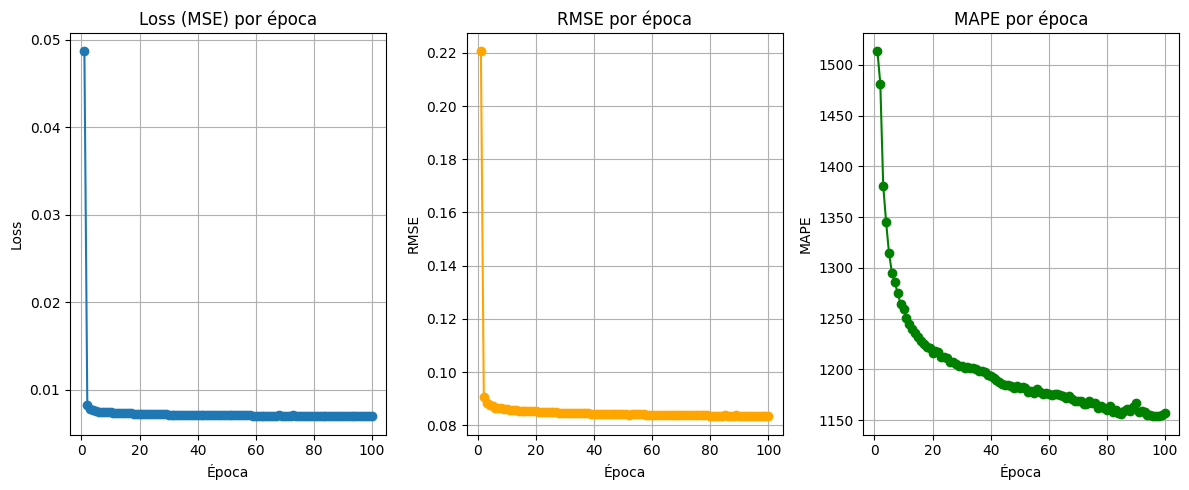

In [8]:
import matplotlib.pyplot as plt

# Extraer métricas del historial
loss = history12.history['loss']
rmse = history12.history['root_mean_squared_error']
mape = history12.history['mean_absolute_percentage_error']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o')
plt.title('Loss (MSE) por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange')
plt.title('RMSE por época')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green')
plt.title('MAPE por época')
plt.xlabel('Época')
plt.ylabel('MAPE')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model12.evaluate(X, y, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - loss: 0.0066 - mean_absolute_percentage_error: 1056.9634 - root_mean_squared_error: 0.0815
Pérdida (MSE): 0.0066
RMSE: 0.0815
MAPE: 1056.9634


Visualización de imagenes

24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 888ms/step


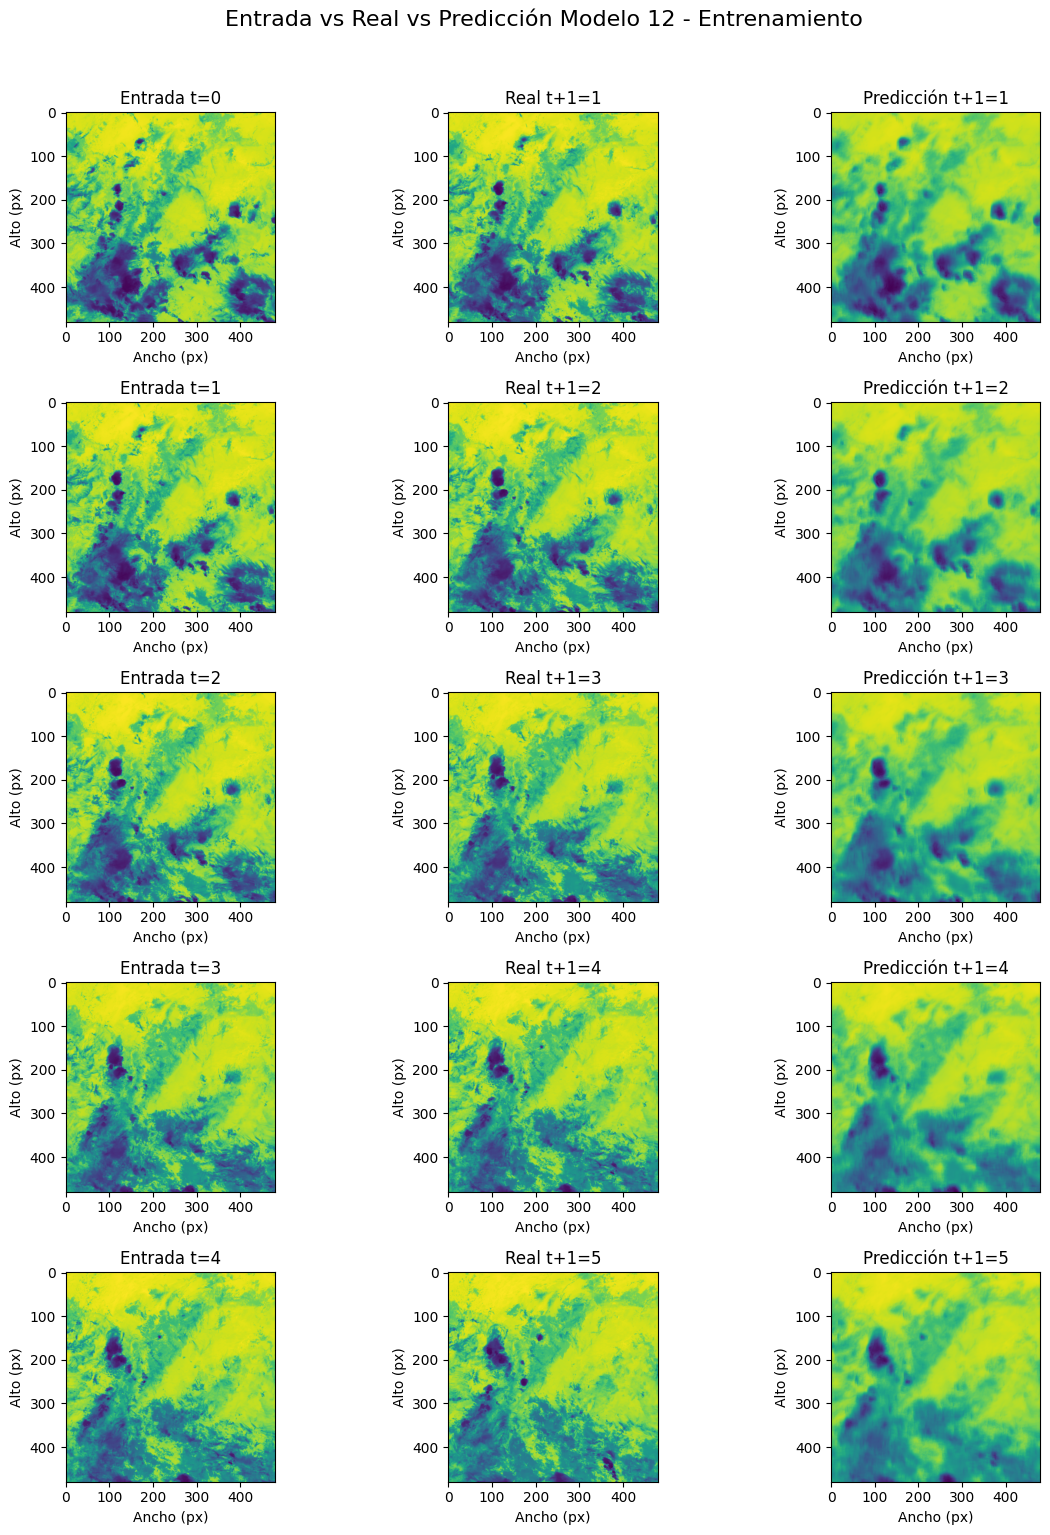

In [9]:
y_pred12 = model12.predict(X)  # Genera las predicciones
mostrar_resultados(
    X, y, y_pred12, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 12 - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

Validación

In [10]:
# Directorio original y reducido
d_feb_1s = 'E:/bandas/banda13/feb_01_07_1s'
d_feb_1s_red = 'E:/bandas/banda13/feb_01_07_1s_red'


# Se llama a la función para redimensionar imágenes
resize_npy_images(d_feb_1s, d_feb_1s_red, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar imágenes
file_list = sorted([f for f in os.listdir(d_feb_1s_red) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
#file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_val = [np.load(os.path.join(d_feb_1s_red, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images_val = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images_val]
images_val = [np.clip(img, 0, 1) for img in images_val]  # Limita los valores al rango [0, 1]

X_val = np.array(images_val[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_val = np.array(images_val[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_val.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_val.shape}")  # Imprime la forma del array de salida

Procesando 167 imágenes
Forma de X: (166, 480, 480, 1)
Forma de y: (166, 480, 480, 1)


Metricas de validación

In [11]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model12.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 781ms/step - loss: 0.0157 - mean_absolute_percentage_error: 951.9803 - root_mean_squared_error: 0.1255
Pérdida (MSE): 0.0157
RMSE: 0.1255
MAPE: 951.9803


Visualización de imagenes con conjunto de validación

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 775ms/step


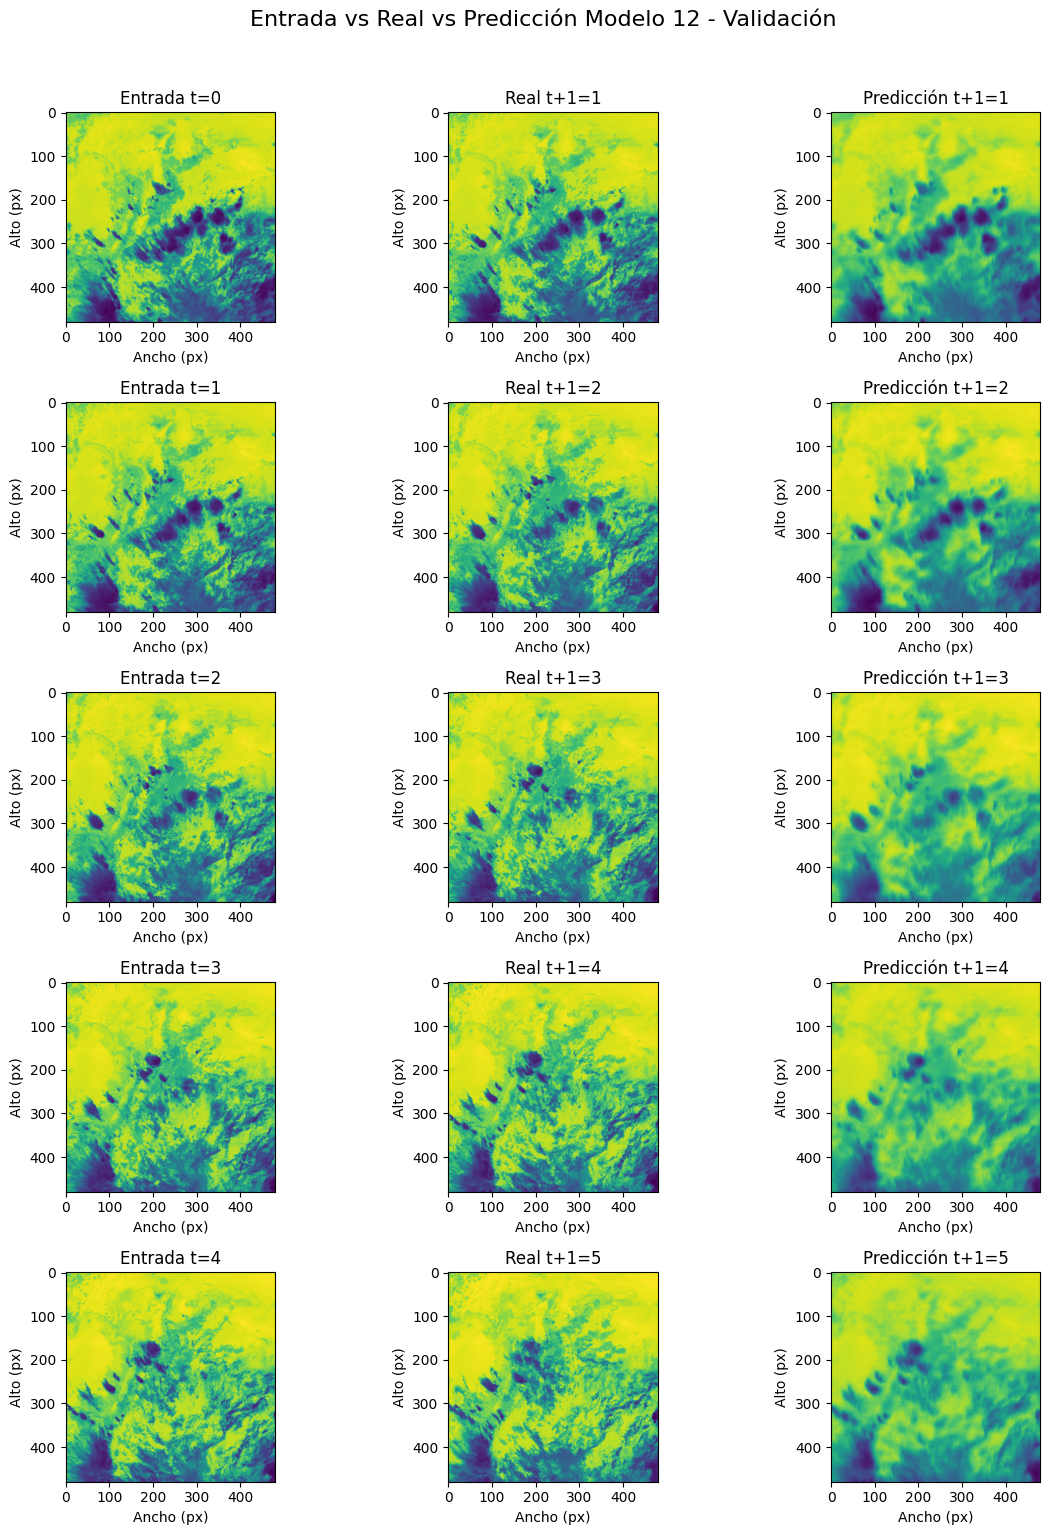

In [12]:
y_pred12_val = model12.predict(X_val)  # Genera las predicciones
mostrar_resultados(
    X_val, y_val, y_pred12_val, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 12 - Validación",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

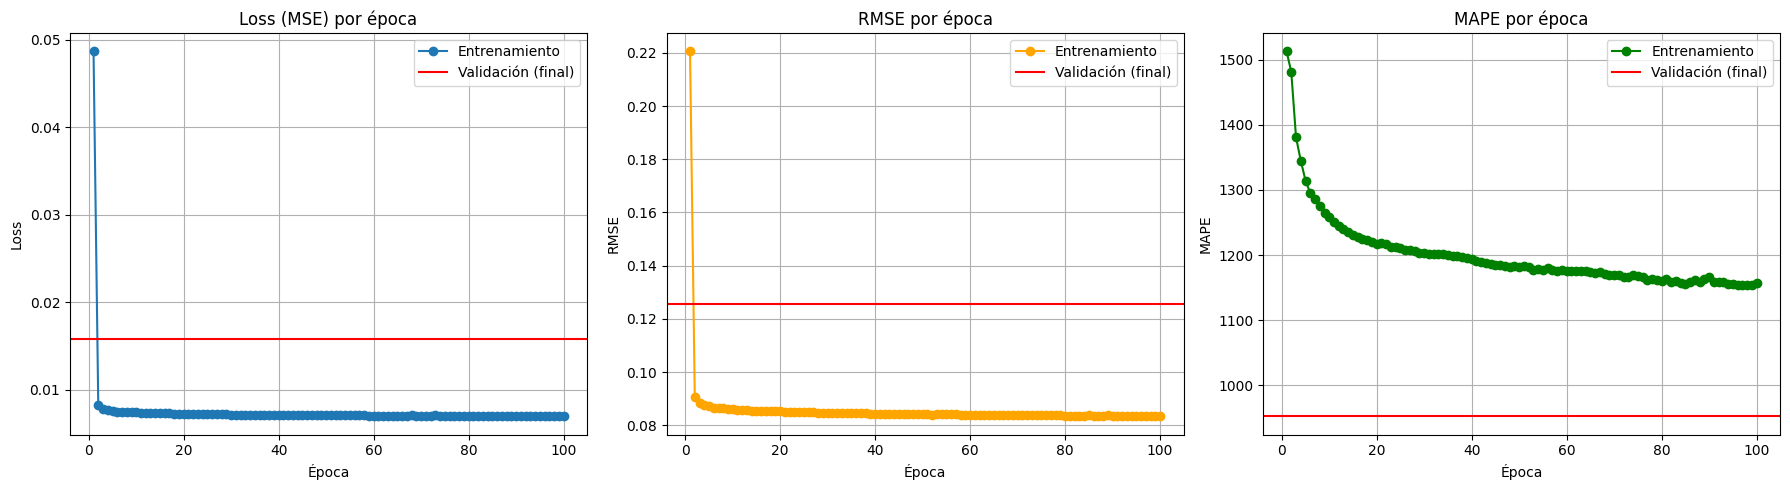

In [13]:

# Extraer métricas de entrenamiento del historial
loss = history12.history['loss']
rmse = history12.history['root_mean_squared_error']
mape = history12.history['mean_absolute_percentage_error']
epochs = range(1, len(loss) + 1)

# Obtener métricas de validación evaluando el modelo en el conjunto de validación
# Asegúrate de que X_val y y_val están definidos y cargados
loss_val, rmse_val, mape_val = model12.evaluate(X_val, y_val, verbose=0) # verbose=0 para no imprimir el progreso

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento')
plt.axhline(y=loss_val, color='r', linestyle='-', label='Validación (final)')
plt.title('Loss (MSE) por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento')
plt.axhline(y=rmse_val, color='red', linestyle='-', label='Validación (final)')
plt.title('RMSE por época')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento')
plt.axhline(y=mape_val, color='red', linestyle='-', label='Validación (final)')
plt.title('MAPE por época')
plt.xlabel('Época')
plt.ylabel('MAPE')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()